<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/PML/Day_19_06_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

import os
os.chdir('/content/drive/MyDrive/CDAC/')

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy import random
from collections import Counter

from numpy.linalg import inv
from numpy.linalg import eig

import matplotlib
from matplotlib import pyplot as plt

import seaborn as sns

import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy.stats import chisquare
from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f
from sklearn.metrics import mean_squared_error


#========================================================================

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

import sklearn
from sklearn.model_selection import train_test_split



import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [40]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')

df =df[['Glucose','BloodPressure','Age','DietType','Outcome']]

x = df.drop('Outcome', axis=1)
y = df.Outcome

diet_dummy = pd.get_dummies(x.DietType, drop_first=True, prefix='Diet').astype(int)
x = x.drop('DietType', axis=1)
x = pd.concat([x, diet_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod3 = sm.Logit(y_train, x_train).fit()
print(mod3.summary())

Optimization terminated successfully.
         Current function value: 0.333614
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      608
Method:                           MLE   Df Model:                            5
Date:                Sat, 06 Jun 2026   Pseudo R-squ.:                  0.4848
Time:                        04:25:12   Log-Likelihood:                -204.84
converged:                       True   LL-Null:                       -397.59
Covariance Type:            nonrobust   LLR p-value:                 3.933e-81
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Glucose           0.0368      0.005      7.867      0.000       0.028       0.046
BloodPressure     0.

In [41]:
mydata = pd.DataFrame([[100,75,50,1,0,1],[100,75,51,1,0,1]], columns = ['Glucose', 'BloodPressure', 'Age', 'Diet_2', 'Diet_3','cont'])

In [42]:
mydata

,Glucose,BloodPressure,Age,Diet_2,Diet_3,cont
0,100,75,50,1,0,1
1,100,75,51,1,0,1


In [43]:
mypreds = mod3.predict(mydata)

mypreds

,0
0,0.067899
1,0.069934


In [44]:
LOR_51 = np.log(0.069934/(1-0.069934))
LOR_51

np.float64(-2.5877036112340317)

In [45]:
LOR_50 = np.log(0.067899/(1-0.067899))
LOR_50

np.float64(-2.6194198709970986)

In [46]:
LOR_51 - LOR_50

np.float64(0.03171625976306691)

---

In [47]:
mydata1 = pd.DataFrame([[100,75,50,1,0,1],[120,75,50,1,0,1]], columns = ['Glucose', 'BloodPressure', 'Age', 'Diet_2', 'Diet_3','cont'])
mydata1

,Glucose,BloodPressure,Age,Diet_2,Diet_3,cont
0,100,75,50,1,0,1
1,120,75,50,1,0,1


In [48]:
mypreds = mod3.predict(mydata1)

mypreds

,0
0,0.067899
1,0.131953


In [49]:
LOR_120 = np.log(0.131953/(1-0.131953))
LOR_120

np.float64(-1.8838000620841853)

In [50]:
LOR_100 = np.log(0.067899/(1-0.067899))
LOR_100

np.float64(-2.6194198709970986)

In [51]:
(LOR_120-LOR_100)/20  ## BCZ we increases the unit by 20 so we are dividing by 20.

np.float64(0.036780990445645666)

coefficient point 0.0317 indicates when the age increses by 1 unit the change/increases in the log od odds ratio in the favor of getting diabetes.

In [5]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')

df =df[['Glucose','BloodPressure','Age','DietType','Outcome']]

x = df.drop('Outcome', axis=1)
y = df.Outcome

diet_dummy = pd.get_dummies(x.DietType, drop_first=True, prefix='Diet').astype(int)
x = x.drop('DietType', axis=1)
x = pd.concat([x, diet_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod3 = sm.Logit(y_train, x_train).fit()
print(mod3.summary())

Optimization terminated successfully.
         Current function value: 0.333614
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      608
Method:                           MLE   Df Model:                            5
Date:                Sat, 06 Jun 2026   Pseudo R-squ.:                  0.4848
Time:                        08:40:53   Log-Likelihood:                -204.84
converged:                       True   LL-Null:                       -397.59
Covariance Type:            nonrobust   LLR p-value:                 3.933e-81
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Glucose           0.0368      0.005      7.867      0.000       0.028       0.046
BloodPressure     0.

# 🔰Ordinal encoding🔰
- variable with inherent rankings or ratings
- preserve logical order

In [6]:
df = pd.DataFrame({
    'Education':[
        'Graduate',
        'PG',
        'High School',
        'Graduate',
        'PG'
    ]
})

education_map = {
    'High School':1,
    'Graduate':2,
    'PG':3
}

df['Education_Encoded'] = (
    df['Education']
    .map(education_map)
)

print(df)

     Education  Education_Encoded
0     Graduate                  2
1           PG                  3
2  High School                  1
3     Graduate                  2
4           PG                  3


# `🔰Frequency encoding🔰`
- variable with inherent rankings or ratings
- preserve logical order

In [9]:
df = pd.DataFrame({'city' : ['mumbai','mumbai','mumbai','delhi','delhi','pune']})
df.value_counts()

,count
city,
mumbai,3
delhi,2
pune,1


In [11]:
freq = df.city.value_counts()
freq

,count
city,
mumbai,3
delhi,2
pune,1


In [13]:
df['city_frequency'] = df.city.map(freq)
df

,city,city_frequency
0,mumbai,3
1,mumbai,3
2,mumbai,3
3,delhi,2
4,delhi,2
5,pune,1


In [16]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.1 MB/s eta 0:00:00


In [17]:
from category_encoders import BinaryEncoder

In [23]:
df = pd.DataFrame({
    'City': [
        'Mumbai',
        'Pune',
        'Delhi',
        'Chennai',
        'Kolkata'
    ]
})


#pip install category_encoders

from category_encoders import BinaryEncoder
encoder = BinaryEncoder(cols=['City'])
df_encoded = encoder.fit_transform(df)
print(df_encoded ,         end='\n\n')

df_encoded = encoder.transform(df)
result = pd.concat([df, df_encoded], axis=1)
print(result)

   City_0  City_1  City_2
0       0       0       1
1       0       1       0
2       0       1       1
3       1       0       0
4       1       0       1

      City  City_0  City_1  City_2
0   Mumbai       0       0       1
1     Pune       0       1       0
2    Delhi       0       1       1
3  Chennai       1       0       0
4  Kolkata       1       0       1


In [24]:
df = pd.DataFrame({
    'City': [
        'Mumbai',
        'Pune',
        'Delhi',
        'Chennai',
        'Kolkata',
        'kol',
        'arv',
        'bha'
    ]
})


#pip install category_encoders

from category_encoders import BinaryEncoder
encoder = BinaryEncoder(cols=['City'])
df_encoded = encoder.fit_transform(df)
print(df_encoded ,         end='\n\n')

df_encoded = encoder.transform(df)
result = pd.concat([df, df_encoded], axis=1)
print(result)


   City_0  City_1  City_2  City_3
0       0       0       0       1
1       0       0       1       0
2       0       0       1       1
3       0       1       0       0
4       0       1       0       1
5       0       1       1       0
6       0       1       1       1
7       1       0       0       0

      City  City_0  City_1  City_2  City_3
0   Mumbai       0       0       0       1
1     Pune       0       0       1       0
2    Delhi       0       0       1       1
3  Chennai       0       1       0       0
4  Kolkata       0       1       0       1
5      kol       0       1       1       0
6      arv       0       1       1       1
7      bha       1       0       0       0


# 🔰Confusion Matrix🔰

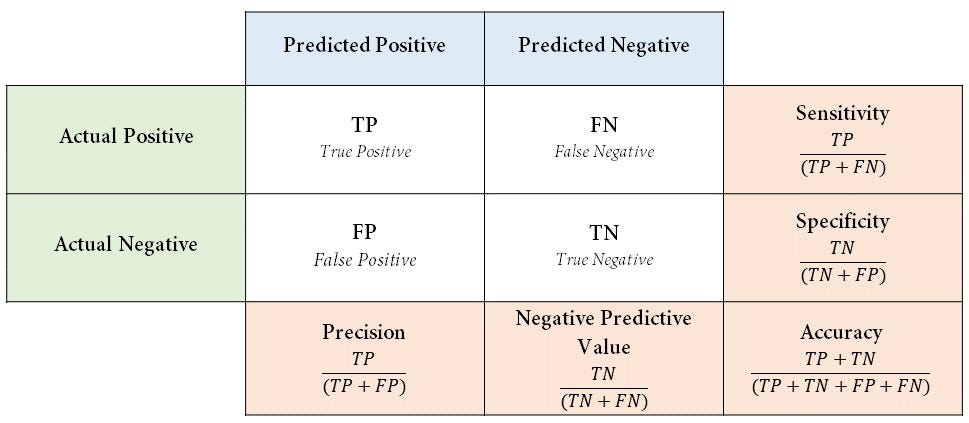